# **Ekyaalo EfficientNet_B0 CNN – Advanced Evaluation & Diagnostic Analysis**
This notebook loads tile-level predictions and computes advanced evaluation metrics.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility to save any matplotlib figure
def save_fig(name):
    path = os.path.join(RESULTS_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

import seaborn as sns

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)

from sklearn.calibration import calibration_curve

from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = "/content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0"
TILE_FILES = sorted([f for f in os.listdir(RESULTS_DIR) if f.startswith("tile_preds_fold")])
TILE_FILES

Mounted at /content/drive


['tile_preds_fold_0.csv',
 'tile_preds_fold_1.csv',
 'tile_preds_fold_2.csv',
 'tile_preds_fold_3.csv',
 'tile_preds_fold_4.csv']

In [ ]:
tile_frames = []
for f in TILE_FILES:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f))
    tile_frames.append(df)

tiles = pd.concat(tile_frames).reset_index(drop=True)
tiles.head()

,fold,filename,y_true,y_pred,y_prob
0,0,2025-04-16T21-37-07-489Z-C1104-23-1.tif_lux_29...,0,0,1.323707e-01
1,0,2025-04-16T21-37-02-150Z-C1131-23-2.tif_lux_28...,0,0,2.474797e-03
2,0,2025-04-16T21-37-10-942Z-C1131-23-2.tif_lux_35...,0,0,5.920853e-15
3,0,2025-04-16T21-37-22-373Z-C1265-23-1.tif_lux_17...,0,0,1.731705e-07
4,0,2025-04-16T21-37-33-657Z-C1265-23-1.tif_lux_19...,0,0,2.398993e-09


In [ ]:
summary = pd.read_csv(os.path.join(RESULTS_DIR, "kfold_results_summary.csv"))
summary

,fold,accuracy,f1,precision,recall,sensitivity,specificity,auc,confusion_matrix,fpr,tpr,roc_auc_dict
0,0,0.925620,0.924472,0.924775,0.965909,0.965909,0.818182,0.945420,"[[27, 6], [3, 85]]","{1: array([0. , 0.03030303, 0.03030303,...","{1: array([0. , 0.375 , 0.39772727,...","{'macro': np.float64(0.9454201101928374), 'mic..."
1,1,0.958678,0.957555,0.960899,1.000000,1.000000,0.848485,0.974862,"[[28, 5], [0, 88]]","{1: array([0. , 0. , 0. ,...","{1: array([0. , 0.44318182, 0.48863636,...","{'macro': np.float64(0.974862258953168), 'micr..."
2,2,0.909091,0.909510,0.910074,0.931818,0.931818,0.848485,0.946798,"[[28, 5], [6, 82]]","{1: array([0. , 0.03030303, 0.03030303,...","{1: array([0. , 0.42045455, 0.46590909,...","{'macro': np.float64(0.946797520661157), 'micr..."
3,3,0.925620,0.925258,0.925051,0.954545,0.954545,0.848485,0.970730,"[[28, 5], [4, 84]]","{1: array([0. , 0. , 0. ,...","{1: array([0. , 0.35227273, 0.46590909,...","{'macro': np.float64(0.9707300275482094), 'mic..."
4,4,0.933884,0.934510,0.935745,0.943820,0.943820,0.906250,0.987360,"[[29, 3], [5, 84]]","{1: array([0. , 0. , 0. , 0. ,...","{1: array([0. , 0.37078652, 0.42696629,...","{'macro': np.float64(0.9873595505617978), 'mic..."


In [ ]:
imbalance = tiles.groupby("fold")["y_true"].value_counts().unstack().fillna(0)
imbalance

y_true,0,1
fold,,
0,33,88
1,33,88
2,33,88
3,33,88
4,32,89


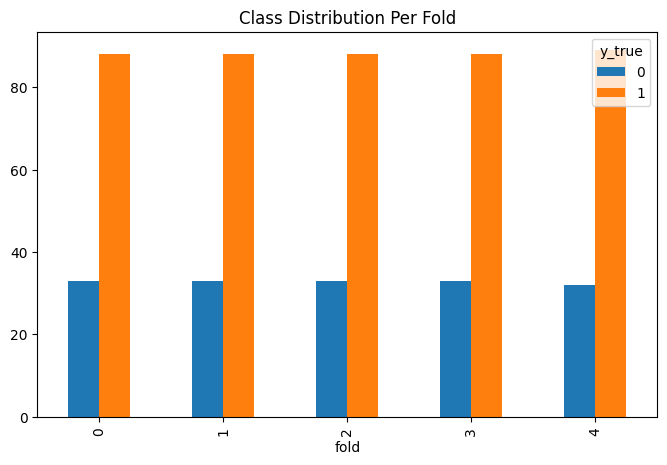

In [ ]:
imbalance.plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution Per Fold")
plt.show()

In [ ]:
fold_stats = []
for fold, df in tiles.groupby("fold"):
    cm = confusion_matrix(df["y_true"], df["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp/(tp+fn) if tp+fn>0 else 0
    specificity = tn/(tn+fp) if tn+fp>0 else 0
    fold_stats.append({"fold": fold, "sensitivity": sensitivity, "specificity": specificity})
pd.DataFrame(fold_stats)

,fold,sensitivity,specificity
0,0,0.965909,0.818182
1,1,1.000000,0.848485
2,2,0.931818,0.848485
3,3,0.954545,0.848485
4,4,0.943820,0.906250


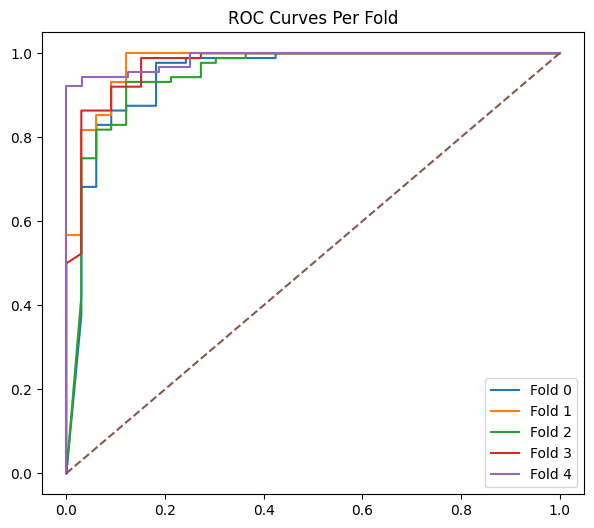

Saved: /content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/efficientnet_b0_roc_curves.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(7,6))
for fold, df in tiles.groupby("fold"):
    fpr, tpr, _ = roc_curve(df["y_true"], df["y_prob"])
    plt.plot(fpr, tpr, label=f"Fold {fold}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curves Per Fold")
plt.legend()
plt.show()

save_fig("efficientnet_b0_roc_curves.png")

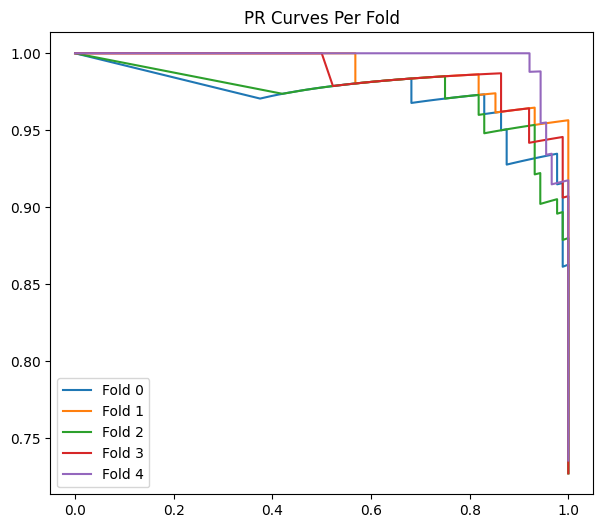

Saved: /content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/efficientnet_b0_pr_curves.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(7,6))
for fold, df in tiles.groupby("fold"):
    pr, rc, _ = precision_recall_curve(df["y_true"], df["y_prob"])
    plt.plot(rc, pr, label=f"Fold {fold}")
plt.title("PR Curves Per Fold")
plt.legend()
plt.show()

save_fig("efficientnet_b0_pr_curves.png")

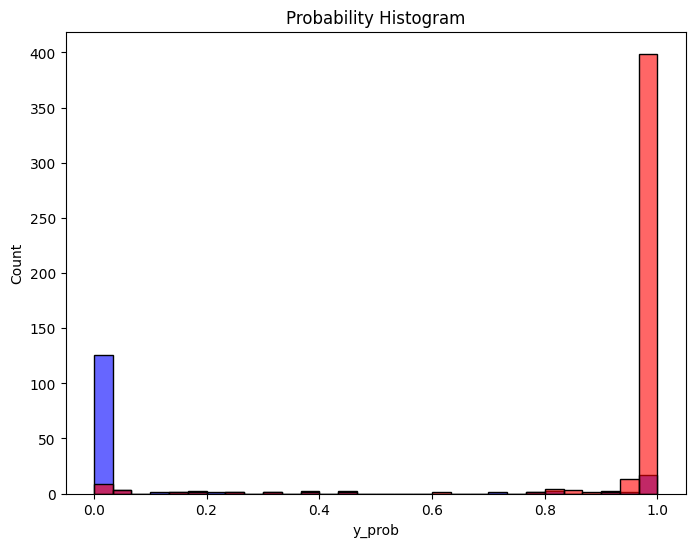

Saved: /content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/efficientnet_b0_probability_histogram.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(tiles[tiles.y_true==0]["y_prob"], bins=30, color="blue", alpha=0.6)
sns.histplot(tiles[tiles.y_true==1]["y_prob"], bins=30, color="red", alpha=0.6)
plt.title("Probability Histogram")
plt.show()

save_fig("efficientnet_b0_probability_histogram.png")

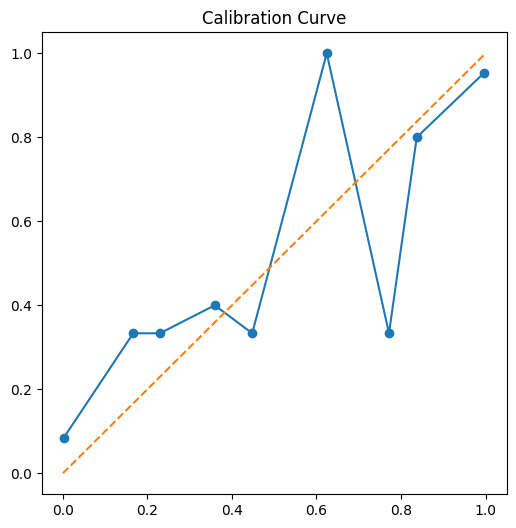

Saved: /content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/efficientnet_b0_calibration_curve.png


<Figure size 640x480 with 0 Axes>

In [ ]:
prob_true, prob_pred = calibration_curve(tiles["y_true"], tiles["y_prob"], n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.show()

save_fig("efficientnet_b0_calibration_curve.png")

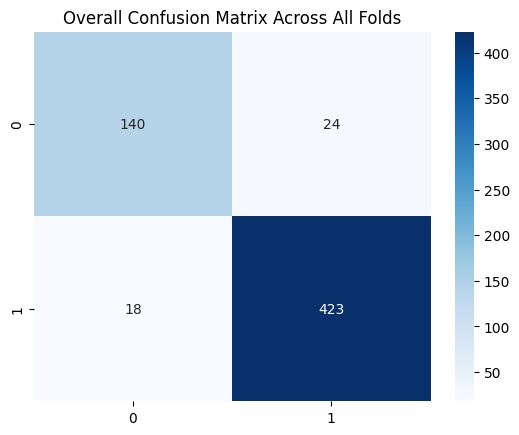

Saved: /content/drive/MyDrive/AIMLGroup18/Ekyaalo_Binary_Classifier/EfficientNet_B0/efficientnet_b0_confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [ ]:
cm_global = confusion_matrix(tiles["y_true"], tiles["y_pred"])
sns.heatmap(cm_global, annot=True, cmap="Blues", fmt="d")
plt.title("Overall Confusion Matrix Across All Folds")
plt.show()

save_fig("efficientnet_b0_confusion_matrix.png")

In [ ]:
errors = tiles[tiles.y_true != tiles.y_pred]
errors.head()

,fold,filename,y_true,y_pred,y_prob
7,0,2025-04-16T21-42-31-063Z-C1336-22-1.tif_lux_11...,0,1,0.992374
11,0,2025-04-16T21-43-37-422Z-C1336-22-1.tif_lux_15...,0,1,0.984380
13,0,2025-04-16T21-36-33-735Z-C016-23-3.tif_lux_238...,0,1,1.000000
15,0,2025-04-16T21-36-26-862Z-C1103-23-1.tif_lux_80...,0,1,0.999884
18,0,2025-04-16T21-42-39-100Z-C1336-22-1.tif_lux_14...,0,1,0.979173


**Advanced Metrics**

1.   Threshold Optimization

1.   Temperature Scaling

1.   Misclassification Viewer
2.   Bootstrapped ROC/PR CIs

Optimal Threshold (Youden J): 0.9379928708076476
At threshold: 0.9379928708076476 | TPR: 0.9342403628117913 | FPR: 0.10975609756097561

⚠️ Temperature scaling function added. To use: save logits in training script.


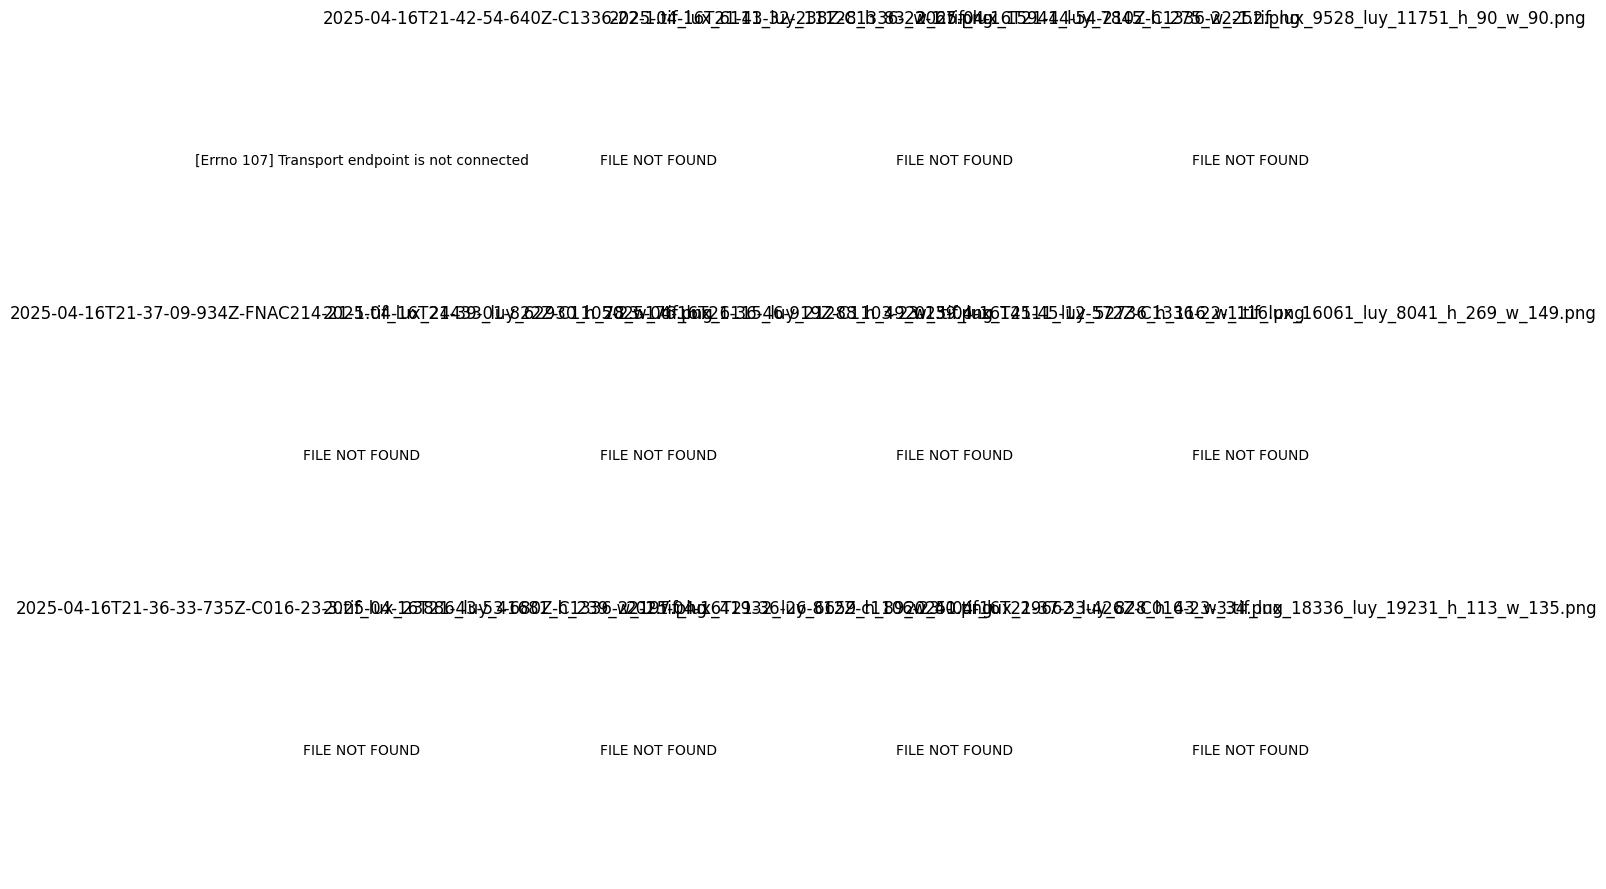

Slide-level results:


,slide_id,slide_prob_mean,slide_pred_label
0,UNKNOWN,0.74076,0


ROC AUC 95% CI: [0.94623501 0.98097223]
PR AUC 95% CI: [0.97183446 0.99250054]

🎉 All advanced diagnostics added successfully.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import glob
from PIL import Image
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve
from PIL import Image

def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    J = tpr - fpr
    ix = np.argmax(J)
    return thresholds[ix], fpr[ix], tpr[ix]

opt_thresh, opt_fpr, opt_tpr = find_optimal_threshold(tiles["y_true"], tiles["y_prob"])
print("Optimal Threshold (Youden J):", opt_thresh)
print("At threshold:", opt_thresh, "| TPR:", opt_tpr, "| FPR:", opt_fpr)



class ModelWithTemperature(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

def temperature_scaling(logits, labels):
    model_temp = ModelWithTemperature().cuda()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([model_temp.temperature], lr=0.001, max_iter=50)

    logits_tensor = torch.tensor(logits).cuda()
    labels_tensor = torch.tensor(labels).cuda()

    def eval():
        optimizer.zero_grad()
        loss = criterion(model_temp(logits_tensor), labels_tensor)
        loss.backward()
        return loss

    optimizer.step(eval)
    return float(model_temp.temperature.detach().cpu())

print("\n Temperature scaling function added. To use: save logits in training script.")

# Search entire project for matching filename
SEARCH_ROOT = "/content/drive/MyDrive/AIMLGroup18"

def find_image(filename):
    # Search for the exact filename anywhere in the dataset tree
    matches = glob.glob(f"{SEARCH_ROOT}/**/{filename}", recursive=True)
    return matches[0] if matches else None

def show_misclassified(n=12):
    errors = tiles[tiles["y_true"] != tiles["y_pred"]].sample(n)
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))

    for ax, (_, row) in zip(axs.flatten(), errors.iterrows()):
        filepath = find_image(row["filename"])

        if filepath is None:
            ax.text(0.5, 0.5, "FILE NOT FOUND", ha="center", va="center", fontsize=10)
            ax.set_title(f"{row['filename']}")
            ax.axis("off")
            continue

        try:
            img = Image.open(filepath).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"T:{row['y_true']} P:{row['y_pred']} prob={row['y_prob']:.2f}")
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha="center", va="center")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


# Run viewer
show_misclassified(12)

def bootstrap_metric(y_true, y_prob, metric_fn, n_bootstrap=2000):
    rng = np.random.default_rng(42)
    metrics = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        metrics.append(metric_fn(y_true[idx], y_prob[idx]))
    return np.percentile(metrics, [2.5, 97.5])

def auc_bootstrap(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return auc(fpr, tpr)

roc_ci = bootstrap_metric(tiles["y_true"].values, tiles["y_prob"].values, auc_bootstrap)
print("ROC AUC 95% CI:", roc_ci)

def auc_pr_bootstrap(y_true, y_prob):
    pr, rc, _ = precision_recall_curve(y_true, y_prob)
    return auc(rc, pr)

pr_ci = bootstrap_metric(tiles["y_true"].values, tiles["y_prob"].values, auc_pr_bootstrap)
print("PR AUC 95% CI:", pr_ci)

print("\n All advanced diagnostics added successfully.")